## Notebook 2 of 5 — Load Flux Tower ET, OpenET, and gridMET Climate

Reads observed flux-tower ET for the selected sites, pulls point-sampled and grid-cell-averaged OpenET via Google Earth Engine, and downloads gridMET daily temperature/precipitation to drive the WBM. Each expensive pull has a cached-CSV reload path (`Data/open_et*/`, `Data/gridmet_cache/`) so re-running this notebook doesn't require hitting GEE again. Runs against the full nationwide flux tower list from notebook 01 (not just sites near a park), since the project's goal is assessing PET/AET method applicability across the whole US, not a handful of parks.

*Part of a 5-notebook pipeline (run in order; each caches its outputs to `Data/` so later notebooks can be re-run without repeating expensive GEE/download steps): `01_select_parks_towers` -> `02_load_flux_openet_gridmet` -> `03_run_wbm` -> `04_validate_and_calibrate` -> `05_figures_and_export`.*

<a href="https://colab.research.google.com/github/rg-smith/remote-sensing-hydro-2025/blob/main/lectures/lecture4-ET.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup Workspace

Import necessary libraries.

In [1]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# IMPORTS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Make the repo root (parent of notebooks/) importable ─────────────────────
import sys
from pathlib import Path as _Path
_REPO_ROOT = _Path.cwd().parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

# ── Standard library ──────────────────────────────────────────────────────────
import importlib
import os
import time
import tempfile
import warnings
import zipfile
from datetime import date
from pathlib import Path

# ── Scientific computing ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr

# ── Geospatial ────────────────────────────────────────────────────────────────
import geopandas as gpd
import rasterio
import shapely
from rasterio.transform import rowcol
from shapely.geometry import Point
from adjustText import adjust_text

# ── Google Earth Engine ───────────────────────────────────────────────────────
import ee
import geemap

# ── Visualization ─────────────────────────────────────────────────────────────
import branca.colormap as cm
import folium
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# ── Statistics & optimization ─────────────────────────────────────────────────
import requests
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.spatial.distance import pdist, squareform

# ── Utilities ─────────────────────────────────────────────────────────────────
from adjustText import adjust_text
from tqdm import tqdm

# ── NPS WBM (local package, repo_root/wbm/) ───────────────────────────────────
import wbm
from wbm import (
    load_wbm_rasters,       # load & cache DEM / soil / Jennings rasters
    extract_point_params,   # sample site params at point locations
    run_pipeline,           # one-call convenience: load → extract → run
)


Authenticate Google Earth Engine

In [2]:
#if not ee.data._credentials:
ee.Authenticate()
ee.Initialize(project='modis-475315')

Define helper functions

In [3]:
# functions needed for this workflow

# this function is used to add a google earth engine layer to an existing folium map,
# for visualization purposes. Folium is a python package that can put rasters/shapefiles on a basemap
# the function below is run using an existing folium map. If the folium map defines is my_map, then
# my_map.add_ee_layer(ee_object,name)
# where ee_object is the object defined in google earth engine, and name is the label in folium
def add_ee_layer(self, ee_object, name):
    try:
        # display ee.Image()
        if isinstance(ee_object, ee.image.Image):
            range = ee.Image(ee_object).reduceRegion(ee.Reducer.percentile([1, 99]),scale=10000)
            vals = range.getInfo()
            min=list(vals.items())[0][1]
            max=list(vals.items())[1][1]
            vis = {'min': min, 'max': max, 'palette': ['0000FF', 'FFFFFF','FF0000']}

            map_id_dict = ee.Image(ee_object).getMapId(vis)
            folium.raster_layers.TileLayer(
            tiles = map_id_dict['tile_fetcher'].url_format,
            attr = 'Google Earth Engine',
            name = name,
            overlay = True,
            control = True
            ).add_to(self)
            colormap = cm.LinearColormap(vmin=min,vmax=max,colors=['blue', 'white','red']).to_step(n=10)
            colormap.caption=name
            self.add_child(colormap)
        # display ee.ImageCollection()
        elif isinstance(ee_object, ee.imagecollection.ImageCollection):
            ee_object_new = ee_object.mosaic()
            map_id_dict = ee.Image(ee_object_new).getMapId(vis_params)
            folium.raster_layers.TileLayer(
            tiles = map_id_dict['tile_fetcher'].url_format,
            attr = 'Google Earth Engine',
            name = name,
            overlay = True,
            control = True
            ).add_to(self)
        # display ee.Geometry()
        elif isinstance(ee_object, ee.geometry.Geometry):
            folium.GeoJson(
            data = ee_object.getInfo(),
            name = name,
            overlay = True,
            control = True
        ).add_to(self)
        # display ee.FeatureCollection()
        elif isinstance(ee_object, ee.featurecollection.FeatureCollection):
            ee_object_new = ee.Image().paint(ee_object, 0, 2)
            map_id_dict = ee.Image(ee_object_new).getMapId(vis_params)
            folium.raster_layers.TileLayer(
            tiles = map_id_dict['tile_fetcher'].url_format,
            attr = 'Google Earth Engine',
            name = name,
            overlay = True,
            control = True
        ).add_to(self)

    except Exception as e:
        print("Could not display {}".format(name))
        print(e)


# to convert a google earth engine image to a python array
def to_array(img,aoi):
  band_arrs = img.sampleRectangle(region=aoi,properties=['scale=1000'],defaultValue=-999)

  band_names=img.bandNames().getInfo()

  for kk in range(len(band_names)):
    if kk==0:
      dat1=np.array(band_arrs.get(band_names[kk]).getInfo())
      dat_full=np.zeros((dat1.shape[0],dat1.shape[1],len(band_names)))
      dat_full[:,:,kk]=dat1
    else:
      dat=np.array(band_arrs.get(band_names[kk]).getInfo())
      dat_full[:,:,kk]=dat
  return(dat_full)

# to calculate an index
def getIndex(image,b1,b2):
  return image.normalizedDifference([b1, b2])

# to calculate a ratio
def getRatio(image1,image2):
  ratio=image1.divide(image2)
  return ratio

# to create a color map from a specific image
def getVisparams(image,aoi):
  range = image.reduceRegion(ee.Reducer.percentile([1, 99]),aoi,300)
  vals = range.getInfo()
  min=list(vals.items())[0][1]
  max=list(vals.items())[1][1]
  visParams = {'min': min, 'max': max, 'palette': ['0000FF', 'FFFFFF','FF0000']}
  return(visParams)

# to get the link to download an earth engine image
def getLink(image,fname,aoi,scale=1000):
  link = image.getDownloadURL({
    'scale': scale,
    'crs': 'EPSG:4326',
    'fileFormat': 'GeoTIFF',
    'region': aoi,
    'name': fname})
  # print(link)
  return(link)

def download_img(img,geom,fname,scale=1000):
    linkname = getLink(img,fname,geom,scale=scale)
    response = requests.get(linkname, stream=True)
    zipped = fname+'.zip'
    with open(zipped, "wb") as handle:
        for data in tqdm(response.iter_content()):
            handle.write(data)

    with zipfile.ZipFile(zipped, 'r') as zip_ref:
        zip_ref.extractall('')
    os.remove(zipped)

# create an earth engine geometry polygon
def addGeometry(min_lon,max_lon,min_lat,max_lat):

  geom = ee.Geometry.Polygon(
      [[[min_lon, max_lat],
        [min_lon, min_lat],
        [max_lon, min_lat],
        [max_lon, max_lat]]])
  return(geom)

def get_imgcollection(date1,date2,geometry,collection_name,band_name,function='mean'):
  collection = ee.ImageCollection(collection_name)
  if function=='mean':
      img = collection.filterDate(date1,date2).select(band_name).mean().clip(geometry)
  if function=='sum':
      img = collection.filterDate(date1,date2).select(band_name).sum().clip(geometry)
 # range = img.reduceRegion(ee.Reducer.percentile([1, 99]),scale=10000)
 # vals = range.getInfo()
 # min=list(vals.items())[0][1]
 # max=list(vals.items())[1][1]
 # visParams = {'min': min, 'max': max, 'palette': ['0000FF', 'FFFFFF','FF0000']}
  return(img)

# load prism data
def get_prism_image(date1,date2,geometry):

  prism = ee.ImageCollection('OREGONSTATE/PRISM/AN81m')
  prism_img = prism.filterDate(date1,date2).select('ppt').mean().clip(geometry)
  return(prism_img) # returns prism average monthly precipitation, in mm

# load landsat 8 data
def get_l8_image(date1,date2,geometry):

  l8 = ee.ImageCollection('LANDSAT/LC08/C01/T1_RT')
  l8_img = l8.filterDate(date1,date2).mean().clip(geometry)
  return(l8_img)

# to export an image to google drive
def export_to_drive(raster,filename,foldername,geometry):
  # Export the image, specifying scale and region.
  task = ee.batch.Export.image.toDrive(**{
      'image': raster,
      'description': filename,
      'folder': foldername,
      'fileNamePrefix': filename,
      'scale': 1000,
      'region': geometry,
      'fileFormat': 'GeoTIFF',
      'formatOptions': {
        'cloudOptimized': 'true'
      },
  })
  task.start()

# to create an elevation raster from the USGS NED in google earth engine from a user-defined geometry
def get_elev(geometry):

  elev = ee.Image('USGS/NED').clip(geometry)
  return(elev)

# to create an elevation raster from the SRTM in google earth engine from a user-defined geometry
def get_srtm(geometry):

  elev = ee.Image('USGS/SRTMGL1_003').clip(geometry)
  return(elev)

# to create a temporally averaged precipitation raster from GPM from a user-defined geometry
def get_gpm_image(date1,date2,geometry):

  gpm = ee.ImageCollection('NASA/GPM_L3/IMERG_MONTHLY_V07')
  gpm_img = gpm.filterDate(date1,date2).select('precipitation').mean().multiply(24*365/12).clip(geometry) # convert from mm/hour to mm/month
  return(gpm_img) # returns gpm average monthly precipitation in mm

# to create a temporally averaged actual ET raster from the openET ensemble from a user-defined geometry
def get_openET_image(date1,date2,geometry):

  openET = ee.ImageCollection('OpenET/ENSEMBLE/CONUS/GRIDMET/MONTHLY/v2_0')
  openET_img = openET.filterDate(date1,date2).select('et_ensemble_mad').mean().clip(geometry)
  return(openET_img)

# to create a temporally averaged reference ET raster from the openET ensemble from a user-defined geometry
def get_RET(date1,date2,geometry):

  ETR = ee.ImageCollection('IDAHO_EPSCOR/GRIDMET')
  ETR_image = ETR.filterDate(date1,date2).select('etr').mean().multiply(365/12).clip(geometry) # convert from mm/day to mm/month
  return(ETR_image)

# load sentinel 2 data
def get_s2_image(date1,date2,geometry):

    s2 = ee.ImageCollection('COPERNICUS/S2')
    s2_img = s2.filterDate(date1,date2).filterBounds(geometry).first().clip(geometry)
    return(s2_img)

# Add EE drawing method to folium (not a function)
folium.Map.add_ee_layer = add_ee_layer

def create_reduce_region_function(geometry,
                                  reducer=ee.Reducer.mean(),
                                  scale=1000,
                                  crs='EPSG:4326',
                                  bestEffort=True,
                                  maxPixels=1e13,
                                  tileScale=4):
  """Creates a region reduction function.

  Creates a region reduction function intended to be used as the input function
  to ee.ImageCollection.map() for reducing pixels intersecting a provided region
  to a statistic for each image in a collection. See ee.Image.reduceRegion()
  documentation for more details.

  Args:
    geometry:
      An ee.Geometry that defines the region over which to reduce data.
    reducer:
      Optional; An ee.Reducer that defines the reduction method.
    scale:
      Optional; A number that defines the nominal scale in meters of the
      projection to work in.
    crs:
      Optional; An ee.Projection or EPSG string ('EPSG:5070') that defines
      the projection to work in.
    bestEffort:
      Optional; A Boolean indicator for whether to use a larger scale if the
      geometry contains too many pixels at the given scale for the operation
      to succeed.
    maxPixels:
      Optional; A number specifying the maximum number of pixels to reduce.
    tileScale:
      Optional; A number representing the scaling factor used to reduce
      aggregation tile size; using a larger tileScale (e.g. 2 or 4) may enable
      computations that run out of memory with the default.

  Returns:
    A function that accepts an ee.Image and reduces it by region, according to
    the provided arguments.
  """

  def reduce_region_function(img):
    """Applies the ee.Image.reduceRegion() method.

    Args:
      img:
        An ee.Image to reduce to a statistic by region.

    Returns:
      An ee.Feature that contains properties representing the image region
      reduction results per band and the image timestamp formatted as
      milliseconds from Unix epoch (included to enable time series plotting).
    """

    stat = img.reduceRegion(
        reducer=reducer,
        geometry=geometry,
        scale=scale,
        crs=crs,
        bestEffort=bestEffort,
        maxPixels=maxPixels,
        tileScale=tileScale)

    return ee.Feature(geometry, stat).set({'millis': img.date().millis()})
  return reduce_region_function

# Define a function to transfer feature properties to a dictionary.
def fc_to_dict(fc):
  prop_names = fc.first().propertyNames()
  prop_lists = fc.reduceColumns(
      reducer=ee.Reducer.toList().repeat(prop_names.size()),
      selectors=prop_names).get('list')

  return ee.Dictionary.fromLists(prop_names, prop_lists)

# generate data frame from image collection
def gee_zonal_mean_img_coll(imageCollection,geometry,scale=1000):
    reduce_iC = create_reduce_region_function(geometry = geometry, scale=scale)
    stat_fc = ee.FeatureCollection(imageCollection.map(reduce_iC)).filter(ee.Filter.notNull(imageCollection.first().bandNames()))
    fc_dict = fc_to_dict(stat_fc).getInfo()

    df = pd.DataFrame(fc_dict)
    df['date'] = pd.to_datetime(df['millis'],unit='ms')
    return(df)

def gee_zonal_mean(date1,date2,geometry,collection_name,band_name,scale=1000):
     imcol = ee.ImageCollection(collection_name).select(band_name).filterDate(date1,date2)
     df = gee_zonal_mean_img_coll(imcol,geometry,scale=scale)
     return(df)

# Convert shapefile to EE object
def shapefile_to_ee(filepath):
    # 1. Read the shapefile
    gdf = gpd.read_file(filepath)
    
    # 2. Ensure it is in WGS84 (required by Earth Engine)
    if gdf.crs != "EPSG:4326":
        gdf = gdf.to_crs("EPSG:4326")
    
    # 3. Convert the geometry to a GeoJSON-like mapping
    # This handles Points, Polygons, and MultiPolygons
    geojson = gdf.__geo_interface__
    
    # 4. Create an ee.FeatureCollection from the GeoJSON
    # You can then get the geometry from the collection
    ee_object = ee.FeatureCollection(geojson)
    
    return ee_object.geometry()


# read in shapefile of National Parks
def get_park_system(save: bool = False, path: str | None = None) -> gpd.GeoDataFrame:
    """Import national park boundary shapefile.

    Downloads NPS park boundary shapefiles via the Data Store REST API.

    Reference:
        https://irmaservices.nps.gov/datastore/v6/documentation
        https://irma.nps.gov/DataStore/Reference/Profile/2224545?lnv=True

    Last updated: September 2025

    Args:
        save: If True, write the result to disk as a GeoPackage.
        path: Directory to save the file. Required when save=True.

    Returns:
        GeoDataFrame of all NPS park boundaries (EPSG:4326).
    """
    download_link = "https://irma.nps.gov/DataStore/DownloadFile/733895"

    # ── Download zip to a temp file ────────────────────────────────────────
    with tempfile.TemporaryDirectory() as tmp_dir:
        tmp_dir = Path(tmp_dir)
        zip_path = tmp_dir / "boundary.zip"
        extract_dir = tmp_dir / "extracted"

        response = requests.get(download_link, stream=True, timeout=120)
        response.raise_for_status()

        with open(zip_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

        # ── Unzip and read shapefile ───────────────────────────────────────
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

        shp_path = extract_dir / "nps_boundary.shp"
        parks = gpd.read_file(shp_path)

        # ── Fix any invalid geometries (mirrors st_make_valid) ─────────────
        parks["geometry"] = parks["geometry"].make_valid()

        # ── Optionally save as GeoPackage ──────────────────────────────────
        if save and path is not None:
            out_path = (
                Path(path)
                / f"nps_park_boundaries_{date.today()}.gpkg"
            )
            parks.to_file(out_path, driver="GPKG")

    return parks


setup for NPS WBM

In [4]:
# ── Import the WBM model from the `wbm` package (repo_root/wbm/) ────────────
# All functions are also available via the `wbm` namespace, e.g. wbm.nps_wbm(...)
import importlib
import wbm

# Reload in case you edited the package mid-session without restarting the kernel
importlib.reload(wbm)

from wbm import (
    # ── Raster utilities ──────────────────────────────────────────────────
    load_wbm_rasters,       # load & cache DEM / soil / Jennings rasters
    extract_point_params,   # sample site params at point locations
    run_pipeline,           # one-call convenience: load → extract → run

    # ── Core model ───────────────────────────────────────────────────────
    nps_wbm,                # single-point daily water balance driver
    run_nps_wbm_points,     # multi-point / multi-GCM wrapper

    # ── Component functions (available if needed for custom workflows) ────
    get_freeze,             # rain/snow partitioning factor
    get_rain, get_snow,     # rainfall and snowfall
    get_melt,               # Hock degree-day snowmelt
    get_snowpack,           # snowpack accumulation
    get_ablation,           # snow sublimation / vapor loss
    get_soil,               # soil water content
    get_d_soil,             # daily change in SWC
    get_aet,                # actual evapotranspiration
    get_storage,            # linear storage reservoir (CSU addition)
    get_oudin_pet,          # Oudin PET with topographic heat-load
    get_hamon_pet,          # Hamon PET
    get_penman_monteith_pet,# FAO-56 Penman-Monteith PET (ETo)
    get_wind_speed_2m,      # 10m -> 2m wind height correction (FAO-56 eq. 47)
    get_daylength,          # astronomical daylength (hours)
    get_gdd,                # growing degree days
    get_deficit,            # climatic water deficit (PET − AET)

    # ── Low-level helpers (rarely called directly) ────────────────────────
    get_svp, actual_vp, atm_press, psyc_constant,
    vapor_curve, clear_sky_rad, outgoing_rad,
)

print(f"WBM functions loaded from: {_REPO_ROOT / 'wbm'}")


WBM functions loaded from: /Users/kcognac/Desktop/Repositories/WBM_ET_Exploration/wbm


Load raster datasets used for the NPS WBM

In [5]:

# Reads the three required GeoTIFFs from `Data/wbm_rasters/`, derives slope
# and aspect from the DEM (Horn's 8-neighbour method, matching
# `terra::terrain(neighbors = 8)`), and caches everything in memory.
#
# **Only needs to run once per session.**  After this, `extract_point_params()`
# works without any path arguments.
#
# | File | Content | Units |
# |---|---|---|
# | `elevation_cropped.tif` | DEM | metres |
# | `water_storage.tif` | Soil water storage capacity | cm (auto-converted → mm) |
# | `merged_jennings2.tif` | Jennings temperature climatology | °C |

# %%
# ── Path to raster directory ──────────────────────────────────────────────────
# Adjust if your rasters live elsewhere.
RASTER_DIR = "../Data/wbm_rasters"

# ── Target CRS ────────────────────────────────────────────────────────────────
# Set to None to keep the native CRS of the rasters (EPSG:4326 for NPS data).
# Set to an EPSG string (e.g. "EPSG:26913") to reproject all rasters before
# sampling — useful when your point coordinates are in a projected CRS.
TARGET_CRS = "EPSG:4326"

try:
    load_wbm_rasters(raster_dir=RASTER_DIR, target_crs=TARGET_CRS)
except ImportError as e:
    print(f"⚠️  Rasters not loaded: {e}")
    print("   Install rasterio and re-run this cell before calling extract_point_params().")
except FileNotFoundError as e:
    print(f"⚠️  Raster file not found:\n   {e}")
    print(f"   Check that RASTER_DIR = '{RASTER_DIR}' is correct.")

Loading WBM rasters from '../Data/wbm_rasters' ...
  DEM loaded        : (2733, 4381)  CRS=PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6378137,298.25723]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",42.5],PARAMETER["central_meridian",-100],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",60],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  Soil loaded       : (3620, 5769)  CRS=EPSG:5070
  Jennings loaded   : (142, 576)  CRS=EPSG:4326
  Reprojecting DEM → EPSG:4326 ...


/Users/kcognac/Desktop/Repositories/WBM_ET_Exploration/wbm/raster_io.py:259: RasterioDeprecationWarning: is_valid is not useful and will be removed in 2.0.0.
  if jtemp_crs is None or not jtemp_crs.is_valid:


  Reprojecting Soil → EPSG:4326 ...
  Computing slope & aspect (Horn's method) ...
  ✓ All rasters loaded and cached.



Define global model settings for NPS WBM

In [6]:
# Set default WBM run parameters here.  These are passed through to
# `nps_wbm()` / `run_nps_wbm_points()` / `run_pipeline()` in later cells.
# Override any of them at call-time as needed.


# ── PET method ────────────────────────────────────────────────────────────────
# One of: "Oudin"  (default, temperature-based, topographic heat-load adjusted)
#         "Hamon"  (temperature + daylength)
#         "Penman-Monteith"  (requires tmax, tmin, and ideally RH / wind data)
PET_METHOD = "Oudin"

# ── Snowmelt ──────────────────────────────────────────────────────────────────
# Hock (2003) degree-day melt factor (mm °C⁻¹ day⁻¹).
# Hock reports ~2.5 for Gooseberry Creek, UT; NPS default is 4.
HOCK_COEF = 4.0

# ── Initial conditions ────────────────────────────────────────────────────────
SNOWPACK_INIT = 0.0   # mm SWE
SOIL_INIT     = 0.0   # mm

# ── CSU additions ─────────────────────────────────────────────────────────────
DIRECT_FRAC  = 0.0    # fraction of rainfall routed directly to runoff (0–1)
RETURN_RATE  = 1.0    # fraction of storage reservoir released per day (0–1]
PET_MULT     = 1    # multiplicative PET bias correction
SOIL_MULT    = 1    # multiplicative adjustment to SWC_Max

# ── Misc ──────────────────────────────────────────────────────────────────────
SHADE_COEFF  = 1.0    # canopy shading coefficient for Oudin PET (0–1)
T_BASE       = 0.0    # base temperature for growing degree days (°C)
TO_INCHES    = True   # True → output fluxes in inches; False → mm

print("✓ Model settings configured:")
print(f"  PET method   : {PET_METHOD}")
print(f"  Hock coef    : {HOCK_COEF} mm °C⁻¹ day⁻¹")
print(f"  Direct frac  : {DIRECT_FRAC}")
print(f"  Return rate  : {RETURN_RATE}")
print(f"  PET mult     : {PET_MULT}   |  Soil mult: {SOIL_MULT}")
print(f"  Output units : {'inches' if TO_INCHES else 'mm'}")


✓ Model settings configured:
  PET method   : Oudin
  Hock coef    : 4.0 mm °C⁻¹ day⁻¹
  Direct frac  : 0.0
  Return rate  : 1.0
  PET mult     : 1   |  Soil mult: 1
  Output units : inches


In [7]:
# Verify setup (quick sanity check)
#
# Runs the model for one synthetic year at a single point to confirm the full
# stack (imports → raster cache → model) is working before you connect real
# climate data.

# %%
rng = np.random.default_rng(0)
_n  = 365
_dates = pd.date_range("2000-01-01", periods=_n)
_doy   = _dates.dayofyear.to_numpy(float)

_test_climate = pd.DataFrame({
    "date":    _dates,
    "x":       -105.5,          # lon — update to match your study area
    "y":        40.0,           # lat
    "ppt_mm":  rng.exponential(3.0, _n),
    "tmean_C": 8 * np.sin(2 * np.pi * (_doy - 80) / 365) + 5 + rng.normal(0, 2, _n),
    "GCM":     "sanity_check",
})

# Use hard-coded params so the test doesn't depend on the rasters being loaded
_test_params = {"Elev": 2400, "Slope": 10, "Aspect": 180,
                "SWC_Max": 150, "J_Temp": 1.5}

_test_result = nps_wbm(
    _test_climate, _test_params,
    pet_method    = PET_METHOD,
    hock_coef     = HOCK_COEF,
    direct_frac   = DIRECT_FRAC,
    return_rate   = RETURN_RATE,
    pet_mult      = PET_MULT,
    soil_mult     = SOIL_MULT,
    shade_coeff   = SHADE_COEFF,
    t_base        = T_BASE,
    to_inches     = False,          # mm for the sanity check
)

_unit = "mm"
print("✓ Sanity check passed — annual water balance totals:")
print(f"  {'Variable':<14}  {'Annual total':>14}")
print(f"  {'-'*30}")
for _col in ["ppt_mm", "RAIN", "SNOW", "MELT", "AET", "RUNOFF", "D"]:
    print(f"  {_col:<14}  {_test_result[_col].sum():>12.1f} {_unit}")

print(f"\n  Peak snowpack : {_test_result['PACK'].max():.1f} {_unit}")
print(f"  Max soil SWC  : {_test_result['SOIL'].max():.1f} {_unit}")
print(f"\n✓ Setup complete — ready to run NPS WBM.\n")

✓ Sanity check passed — annual water balance totals:
  Variable          Annual total
  ------------------------------
  ppt_mm                1205.4 mm
  RAIN                   816.5 mm
  SNOW                   389.0 mm
  MELT                   301.3 mm
  AET                    467.4 mm
  RUNOFF                 500.4 mm
  D                        2.0 mm

  Peak snowpack : 87.6 mm
  Max soil SWC  : 150.0 mm

✓ Setup complete — ready to run NPS WBM.



In [8]:
# NPS WBM Quick-reference: key function signatures
#
# ```python
# # ── Extract site params at your points from the loaded rasters ────────────
# point_params_df = extract_point_params(points_df)
# # points_df needs columns: x (lon), y (lat)
# # Returns:  Elev, Slope, Aspect, SWC_Max, J_Temp  added to points_df
#
# # ── Run for a single point ────────────────────────────────────────────────
# result = nps_wbm(
#     daily_df     = climate_df,        # date, x, y, ppt_mm, tmean_C [, GCM]
#     point_params = point_params_df.iloc[0].to_dict(),
#     pet_method   = PET_METHOD,
#     **{k: v for k, v in globals().items()
#        if k in ("hock_coef","direct_frac","return_rate","pet_mult",
#                 "soil_mult","shade_coeff","t_base","to_inches")},
# )
#
# # ── Run for multiple points / GCMs ───────────────────────────────────────
# results = run_nps_wbm_points(
#     climate_data    = climate_df,
#     point_params_df = point_params_df,
#     pet_method      = PET_METHOD,
#     aggregate       = True,           # False → keep per-point rows
#     ret_final_cond  = False,          # True → chain into next time period
# )
#
# # ── One-call pipeline (load → extract → run) ─────────────────────────────
# results = run_pipeline(
#     climate_data = climate_df,
#     points_df    = points_df,
#     raster_dir   = RASTER_DIR,
#     pet_method   = PET_METHOD,
# )
# ```

*Loading prerequisites saved by notebook 01 — needed if you're starting this notebook in a fresh kernel.*

In [9]:
# ── Load prerequisites from notebook 01 (fresh kernel = these aren't in memory) ──
# towers_near (park-adjacent subset) is no longer loaded here -- this notebook
# now downloads for every nationwide site in flux_towers.csv. Notebook 09 filters
# these cached outputs down to the park-adjacent subset itself.
flux_towers = pd.read_csv("../Data/geo_data/flux_towers.csv")
print(f"Loaded {len(flux_towers)} flux tower records (nationwide) from notebook 01's cache.")


Loaded 81 flux tower records (nationwide) from notebook 01's cache.


Now, we'll read in flux tower ET data.

In [10]:
# ── Read and combine monthly flux tower ET data for all selected sites ─────────

flux_frames = []
missing_files = []

for row in flux_towers.itertuples():
    fpath = f"../Data/flux_ET_dataset/monthly_data_files/{row.site}_monthly_data.csv"
    
    if not os.path.exists(fpath):
        missing_files.append(row.site)
        continue
    
    df = pd.read_csv(fpath, parse_dates=["date"])
    df = df[df["date"] >= "2016-01-01"]   # ← filter to 2016 onwards
    df["site"] = row.site
    flux_frames.append(df)

# Report any missing files before combining
if missing_files:
    print(f"⚠️  No CSV found for {len(missing_files)} site(s): {missing_files}")
    print(   "   Check that the site ID in flux_towers matches the filename exactly.\n")

# Combine
flux_monthly = (
    pd.concat(flux_frames, ignore_index=True)
    .sort_values(["site", "date"])
    .reset_index(drop=True)
)

print(f"Sites loaded      : {flux_monthly['site'].nunique()} / {len(flux_towers)}")
print(f"Shape             : {flux_monthly.shape}")
print(f"Date range        : {flux_monthly['date'].min().date()} → "
      f"{flux_monthly['date'].max().date()}")
print(f"\nColumns           : {flux_monthly.columns.tolist()}")
print(f"\nRows per site:")
print(flux_monthly["site"].value_counts().sort_index().to_string())
print(f"\nSample output:")
print(flux_monthly.head(12).to_string(index=False))

Sites loaded      : 81 / 81
Shape             : (2550, 183)
Date range        : 2016-01-31 → 2022-05-31

Columns           : ['date', 'rh', 'flux', 'ebr', 'EToF_filtered', 'rso', 'EToF', 'ebr_5day_clim', 'sw_out', 't_max', 'ebr_corr', 'Rn', 'energy', 'lw_in', 't_min', 'sw_in', 'H', 'theta_1', 'lw_out', 'LE', 'wd', 'ws', 'ebc_cf', 'flux_corr', 'LE_corr', 'H_corr', 't_avg', 'theta_mean', 'G', 'theta_2', 'Rn_subday_gaps', 'ET_fill_val', 'G_subday_gaps', 'ET_gap', 'ET', 'ET_corr', 'gridMET_ETo', 'gridMET_prcp', 'H_subday_gaps', 'ET_fill', 'ppt', 'LE_subday_gaps', 'gridMET_ETr', 'site', 'es', 't_dew', 'vp', 'vpd', 'H_1_1_1', 'theta_14', 'RH_1_1_1', 'g_4', 'theta_6', 'WS_1_3_1', 'theta_9', 'theta_11', 'theta_15', 'g_3', 'WD_1_1_1', 'theta_4', 'WD_1_3_1', 'theta_16', 'theta_17', 'theta_7', 'theta_8', 'g_2', 'RH_1_3_1', 'theta_5', 'theta_13', 'theta_12', 'SW_IN_1_1_1', 'LE_1_2_1', 'NETRAD_1_1_1', 'WS_1_2_1', 'theta_3', 'T_SONIC_1_1_1', 'T_SONIC_1_3_1', 'LE_1_1_1', 'WS_1_1_1', 'H_1_3_1', 'RH_1_

/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_68100/3324018540.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["site"] = row.site
/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_68100/3324018540.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["site"] = row.site
/var/folders/gh/wltw2syx0zl4vqj9grs2stz00000gn/T/ipykernel_68100/3324018540.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Co

Plot flux tower data from individual sites

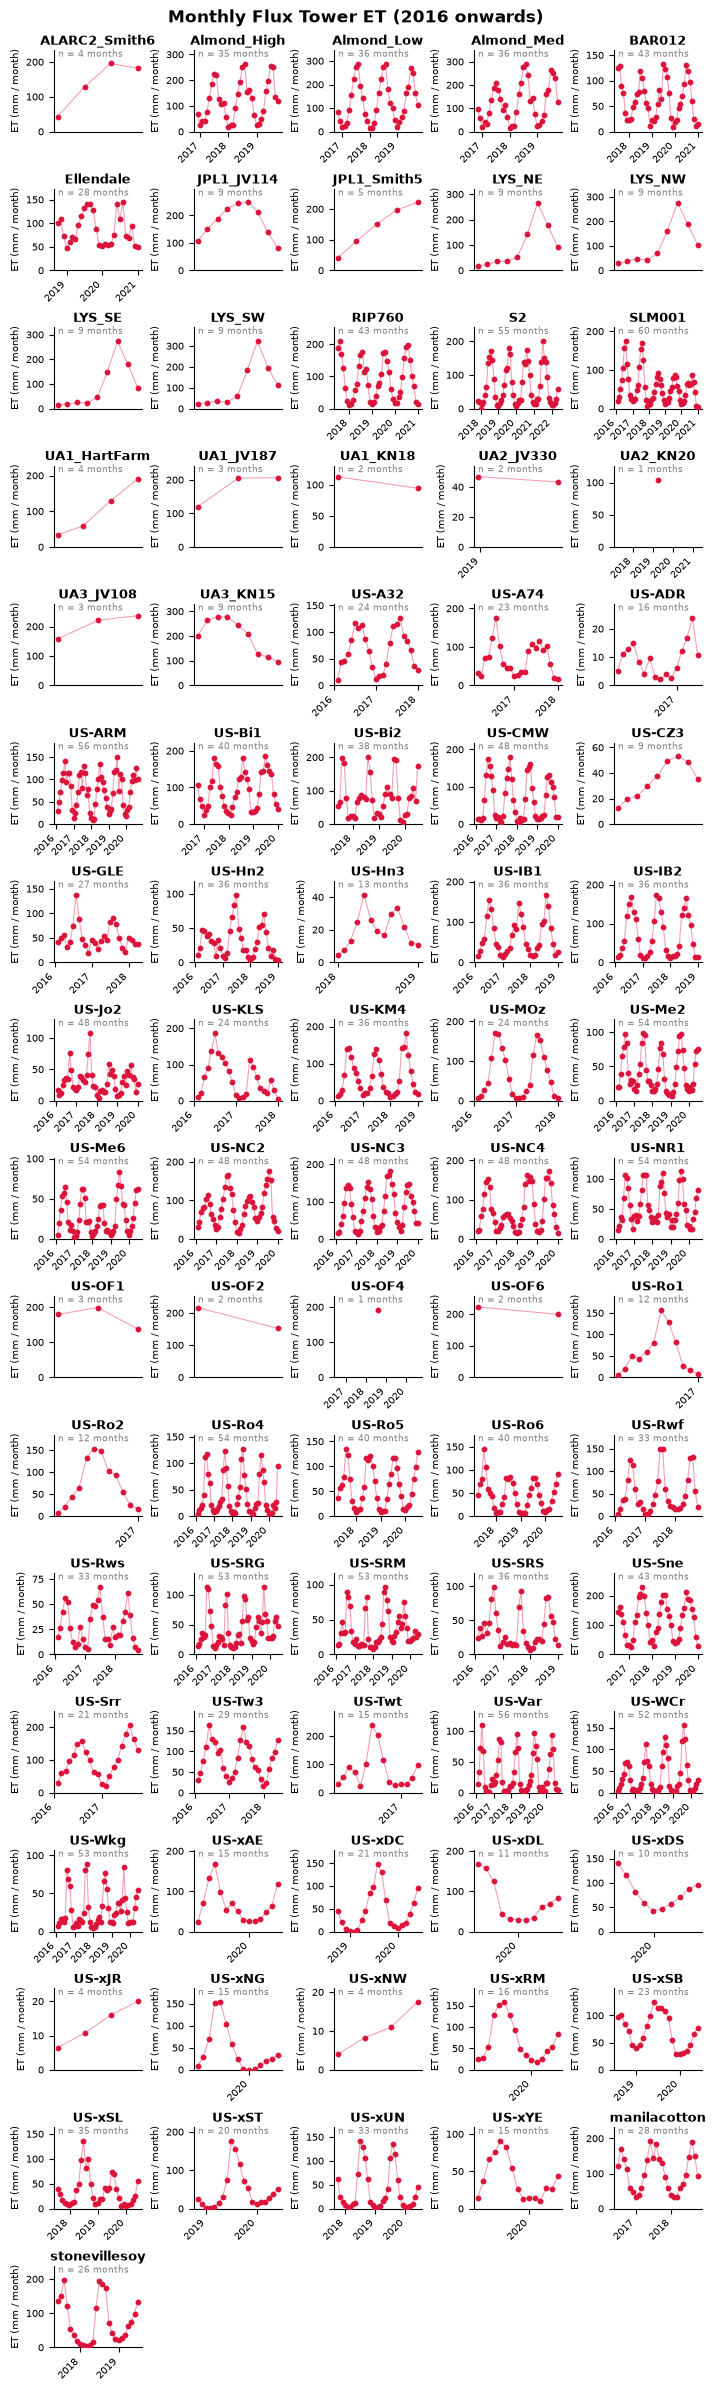

In [11]:

# ── Layout ────────────────────────────────────────────────────────────────────
sites   = sorted(flux_monthly["site"].unique())
n_sites = len(sites)
n_cols  = 5
n_rows  = int(np.ceil(n_sites / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7, n_rows * 1.4),
    sharey=False,
    constrained_layout=True,
)
axes_flat = axes.flatten()

# ── Plot each site ────────────────────────────────────────────────────────────
for ax, site in zip(axes_flat, sites):
    sub = flux_monthly[flux_monthly["site"] == site].sort_values("date")

    ax.scatter(sub["date"], sub["ET_corr"],
               color="crimson", s=10, zorder=3, label="Flux tower ET")
    ax.plot(sub["date"], sub["ET_corr"],
            color="crimson", linewidth=0.8, alpha=0.4)

    ax.set_title(site, fontsize=9, fontweight="bold", pad=4)
    ax.set_ylabel("ET (mm / month)", fontsize=7)
    ax.tick_params(axis="both", labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(bottom=0)
    ymax = ax.get_ylim()[1]
    ax.set_ylim(top=ymax * 1.15)  # add 10% headroom

    # Annotate with number of months available
    n_months = sub["ET_corr"].notna().sum()
    ax.annotate(f"n = {n_months} months",
                xy=(0.05, 0.92), xycoords="axes fraction",
                fontsize=6.5, color="grey")

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# ── Hide unused axes ──────────────────────────────────────────────────────────
for ax in axes_flat[n_sites:]:
    ax.set_visible(False)

fig.suptitle(
    "Monthly Flux Tower ET (2016 onwards)",
    fontsize=12, fontweight="bold",
)

plt.savefig("../Data/open_et/flux_tower_et_faceted.png", dpi=600, bbox_inches="tight")
plt.show()

Now, we'll read in OpenET data for each flux tower point. Note, a subsequent code chunk reads in previously downloaded data.

In [12]:
# ── Shared OpenET config ──────────────────────────────────────────────────────
# Defined unconditionally (not inside either read_prev branch below) since both
# the point-sampled and gridcell-averaged OpenET pulls need it, and previously
# it only existed inside the point-sampled cell'''s non-default else-branch —
# if that cell was left at its default read_prev=True (skip/reload-from-cache)
# while this next one ran fresh, START_DATE/END_DATE/SCALE/ENSEMBLE_BANDS were
# never defined, raising NameError.
START_DATE = "2016-01-01"
END_DATE   = "2023-12-31"
SCALE      = 30                         # OpenET native resolution (metres)
START_YEAR = pd.Timestamp(START_DATE).year
END_YEAR   = pd.Timestamp(END_DATE).year

ENSEMBLE_BANDS = {
    "et_ensemble_mad":     "et_ensemble_mm",
    "et_ensemble_mad_min": "et_ensemble_min_mm",
    "et_ensemble_mad_max": "et_ensemble_max_mm",
}

# NOTE: this cell used to also build a nationwide `towers_ee` EE
# FeatureCollection here (via geemap.geopandas_to_ee) for cell 25 to batch
# reduceRegions() across all sites at once. That approach was replaced by a
# per-site loop (see cell 25) after discovering OpenET's monthly ensemble/
# model collections are internally tiled -- batching multiple sites (or even
# a single year) together still exceeded GEE's 5000-element getInfo() cap at
# nationwide scale. flux_towers itself (with its x/y columns) is all cell 25
# needs now.


def ee_fc_to_df(fc):
    """
    Convert an ee.FeatureCollection to a pandas DataFrame without relying on
    geemap.ee_to_df(), which errors with "Cannot specify both 'axis' and
    'index'/'columns'" on every site under some geemap/pandas version
    combinations. This parses the raw getInfo() JSON directly instead --
    slightly slower for very large collections, but avoids the incompatibility
    entirely.
    """
    features = fc.getInfo()["features"]
    rows = [f["properties"] for f in features]
    return pd.DataFrame(rows)


In [13]:
# ── Incremental caching: only fetch OpenET for sites not already cached ──────
OPENET_CACHE = "../Data/open_et/openet_timeseries.csv"

existing_openet_df, missing_openet_sites = wbm.load_and_filter_missing(
    all_sites=flux_towers["site"].tolist(),
    cache_path=OPENET_CACHE,
    site_col="site",
    parse_dates=["date"],
)

if not missing_openet_sites:
    print(f"All {len(flux_towers)} sites already cached in {OPENET_CACHE} -- skipping GEE.")
    openet_df = existing_openet_df

    ENSEMBLE_COL = "et_ensemble_mm"
    MIN_COL      = "et_ensemble_min_mm"
    MAX_COL      = "et_ensemble_max_mm"
    MODEL_COLS   = [c for c in openet_df.columns
                    if c.startswith("et_") and c not in
                    [ENSEMBLE_COL, MIN_COL, MAX_COL]]

    print(f"openet_df shape : {openet_df.shape}")
    print(f"Sites           : {sorted(openet_df['site'].unique())}")
    print(f"Date range      : {openet_df['date'].min().date()} \u2192 "
        f"{openet_df['date'].max().date()}")
    print(f"ET columns      : {[ENSEMBLE_COL, MIN_COL, MAX_COL] + MODEL_COLS}")
    print(f"\nSample:")
    print(openet_df.head(6).to_string(index=False))

else:
    print(f"Fetching OpenET for {len(missing_openet_sites)} new site(s): "
          f"{missing_openet_sites}")
    print(f"({len(flux_towers) - len(missing_openet_sites)} site(s) already cached, skipped.)")

    # Build a site -> ee.Geometry.Point lookup for just the missing sites.
    #
    # NOTE: this used to batch reduceRegions() across ALL missing sites in one
    # call per image (via an EE FeatureCollection), then flatten across the
    # full date range (or, after the first fix attempt, per year) into a
    # single getInfo() call. Both still hit GEE's "Collection query aborted
    # after accumulating over 5000 elements" error at nationwide scale --
    # OpenET's monthly ensemble/model collections turn out to be internally
    # tiled (more images behind the scenes than one per calendar month), so
    # even one year x ~80 sites overflowed the cap. Switched to a per-site
    # loop instead (mirroring the gridMET climate cell below, which already
    # does one point x full date range per call without issue) -- this caps
    # the elements in each single request to whatever one site's point
    # actually touches, regardless of how many tiles exist underneath.
    site_geoms_missing = {
        row.site: ee.Geometry.Point([row.x, row.y])
        for row in flux_towers.itertuples()
        if row.site in missing_openet_sites
    }

    # Individual models: each is its own collection with a single 'et' band
    MODEL_COLLECTIONS = {
        "disalexi": "projects/openet/assets/disalexi/conus/gridmet/monthly/v2_0",
        "eemetric": "projects/openet/assets/eemetric/conus/gridmet/monthly/v2_0",
        "geesebal": "projects/openet/assets/geesebal/conus/gridmet/monthly/v2_0",
        "ptjpl":    "projects/openet/assets/ptjpl/conus/gridmet/monthly/v2_0",
        "sims":     "projects/openet/assets/sims/conus/gridmet/monthly/v2_0",
        "ssebop":   "projects/openet/assets/ssebop/conus/gridmet/monthly/v2_0",
    }

    # ── Shared per-site sampling function ─────────────────────────────────────────
    def sample_point_timeseries(ic, geom, bands, site_id):
        """
        Sample a multi-band ImageCollection at a single point across the full
        date range in one call. Returns a tidy DataFrame with columns:
        site, date, <band1>, <band2>, ...
        """
        def _sample_img(image):
            date = image.date().format("YYYY-MM-dd")
            vals = image.reduceRegion(
                reducer=ee.Reducer.first(),
                geometry=geom,
                scale=SCALE,
                bestEffort=True,
                maxPixels=1e9,
            )
            props = {"site": site_id, "date": date}
            for b in bands:
                props[b] = vals.get(b)
            return ee.Feature(None, props)

        fc = ee.FeatureCollection(ic.map(_sample_img))
        df = ee_fc_to_df(fc)
        if df.empty:
            return df
        df["date"] = pd.to_datetime(df["date"])

        # Coerce every band column to numeric here, per-site, before any
        # concatenation across sites happens. If a site returns None for a
        # band on every date (e.g. right at the edge of OpenET coverage),
        # pandas infers that column as dtype=object for this one site's
        # frame; concatenating an object-dtype frame with other sites'
        # float64 frames can silently upcast the WHOLE merged column to
        # object, which then breaks matplotlib's fill_between()/isfinite()
        # downstream ("ufunc 'isfinite' not supported for the input
        # types"). errors="coerce" turns any leftover non-numeric value
        # into a clean NaN instead.
        for b in bands:
            df[b] = pd.to_numeric(df[b], errors="coerce")

        return df

    # ── 1. Ensemble collection (mean + min + max), one site at a time ─────────────
    print("Fetching OpenET ensemble (mean / min / max) ...")

    ensemble_ic = (
        ee.ImageCollection("projects/openet/assets/ensemble/conus/gridmet/monthly/v2_0")
        .select(list(ENSEMBLE_BANDS.keys()))
        .filterDate(START_DATE, END_DATE)
    )

    ensemble_frames = []
    for site_id, geom in site_geoms_missing.items():
        print(f"    {site_id} ...", end=" ")
        try:
            df = sample_point_timeseries(ensemble_ic, geom, list(ENSEMBLE_BANDS.keys()), site_id)
            if df.empty:
                print("no data")
                continue
            ensemble_frames.append(df)
            print(f"\u2713  {df.shape}")
        except Exception as e:
            print(f"\u26a0\ufe0f  failed: {e}")

    ensemble_df = (
        pd.concat(ensemble_frames, ignore_index=True) if ensemble_frames
        else pd.DataFrame(columns=["site", "date"] + list(ENSEMBLE_BANDS.keys()))
    )
    ensemble_df = (
        ensemble_df
        .rename(columns=ENSEMBLE_BANDS)
        .dropna(subset=list(ENSEMBLE_BANDS.values()))
        .sort_values(["site", "date"])
        .reset_index(drop=True)
    )
    print(f"  \u2713 Ensemble: {ensemble_df.shape}")

    # ── 2. Individual models, one site at a time ──────────────────────────────────
    model_frames = []

    for model_name, collection_id in MODEL_COLLECTIONS.items():
        print(f"  Fetching {model_name} ...")
        col_name = f"et_{model_name}_mm"
        try:
            ic = (
                ee.ImageCollection(collection_id)
                .select("et")
                .filterDate(START_DATE, END_DATE)
            )
            site_dfs = []
            for site_id, geom in site_geoms_missing.items():
                df = sample_point_timeseries(ic, geom, ["et"], site_id)
                if df.empty:
                    continue
                df = df.rename(columns={"et": col_name}).dropna(subset=[col_name])
                site_dfs.append(df[["site", "date", col_name]])
            if site_dfs:
                model_df = pd.concat(site_dfs, ignore_index=True)
                model_frames.append(model_df)
                print(f"    \u2713 {model_name}: {model_df.shape}")
            else:
                print(f"    \u26a0\ufe0f  {model_name}: no data for any site")
        except Exception as e:
            print(f"    \u26a0\ufe0f  {model_name} failed: {e}")

    # ── 3. Merge ensemble + all models on (site, date) ────────────────────────────
    print("\nMerging ensemble and model outputs ...")

    new_openet_df = ensemble_df.copy()
    for df in model_frames:
        new_openet_df = new_openet_df.merge(df, on=["site", "date"], how="outer")

    et_cols = [c for c in new_openet_df.columns if c.startswith("et_")]

    # Defensive re-coercion after the outer merges, on top of the per-site
    # coercion in sample_point_timeseries() -- belt-and-suspenders against
    # any object-dtype ET column reaching the cache/plots downstream.
    for c in et_cols:
        new_openet_df[c] = pd.to_numeric(new_openet_df[c], errors="coerce")

    new_openet_df = (
        new_openet_df
        .sort_values(["site", "date"])
        .reset_index(drop=True)
    )
    print(f"\nNew rows shape : {new_openet_df.shape}")
    print(f"New sites      : {new_openet_df['site'].nunique()}")
    if len(new_openet_df):
        print(f"Date range     : {new_openet_df['date'].min().date()} \u2192 "
              f"{new_openet_df['date'].max().date()}")
    print(f"ET columns     : {et_cols}")

    # ── 4. Merge with existing cache and save ────────────────────────────────────
    openet_df = wbm.merge_and_save_cache(
        cache_path=OPENET_CACHE,
        existing_df=existing_openet_df,
        new_rows_df=new_openet_df,
        sort_cols=["site", "date"],
    )
    print(f"\nSaved to {OPENET_CACHE}")
    print(f"Combined shape : {openet_df.shape}, {openet_df['site'].nunique()} sites")


Fetching OpenET for 9 new site(s): ['US-IB1', 'US-IB2', 'US-KM4', 'US-NC2', 'US-NC3', 'US-NC4', 'US-xDL', 'US-xDS', 'US-xSB']
(72 site(s) already cached, skipped.)
Fetching OpenET ensemble (mean / min / max) ...
    US-IB1 ... ✓  (2400, 5)
    US-IB2 ... ✓  (2400, 5)
    US-KM4 ... ✓  (2400, 5)
    US-NC2 ... ✓  (2400, 5)
    US-NC3 ... ✓  (2400, 5)
    US-NC4 ... ✓  (2400, 5)
    US-xDL ... ✓  (2400, 5)
    US-xDS ... ✓  (2400, 5)
    US-xSB ... ✓  (2400, 5)
  ✓ Ensemble: (0, 5)
  Fetching disalexi ...
    ✓ disalexi: (0, 3)
  Fetching eemetric ...
    ✓ eemetric: (0, 3)
  Fetching geesebal ...
    ✓ geesebal: (0, 3)
  Fetching ptjpl ...
    ✓ ptjpl: (0, 3)
  Fetching sims ...
    ✓ sims: (0, 3)
  Fetching ssebop ...
    ✓ ssebop: (0, 3)

Merging ensemble and model outputs ...

New rows shape : (0, 11)
New sites      : 0
ET columns     : ['et_ensemble_mm', 'et_ensemble_max_mm', 'et_ensemble_min_mm', 'et_disalexi_mm', 'et_eemetric_mm', 'et_geesebal_mm', 'et_ptjpl_mm', 'et_sims_mm', 'et

Now we also download OpenET spatially averaged over the full ~4 km GridMET grid cell for each site. This gridcell-averaged dataset is the appropriate reference for the NPS WBM, which runs at the GridMET 4 km scale. The point-sampled OpenET above is retained for comparison against flux-tower observations.

In [14]:
# ── Incremental caching: only fetch gridcell OpenET for sites not already cached ──
OPENET_GRIDCELL_CACHE = "../Data/open_et_gridcell/openet_gridcell_timeseries.csv"

existing_gc_df, missing_gc_sites = wbm.load_and_filter_missing(
    all_sites=flux_towers["site"].tolist(),
    cache_path=OPENET_GRIDCELL_CACHE,
    site_col="site",
    parse_dates=["date"],
)

os.makedirs('../Data/open_et_gridcell', exist_ok=True)

if not missing_gc_sites:
    print(f"All {len(flux_towers)} sites already cached in {OPENET_GRIDCELL_CACHE} -- skipping GEE.")
    openet_gridcell_df = existing_gc_df

    print(f'openet_gridcell_df shape : {openet_gridcell_df.shape}')
    print(f'Sites                    : {sorted(openet_gridcell_df["site"].unique())}')
    print(f'Date range               : {openet_gridcell_df["date"].min().date()} -- '
        f'{openet_gridcell_df["date"].max().date()}')
    print(f'\nSample:')
    print(openet_gridcell_df.head(6).to_string(index=False))

else:
    print(f"Fetching gridcell OpenET for {len(missing_gc_sites)} new site(s): {missing_gc_sites}")
    print(f"({len(flux_towers) - len(missing_gc_sites)} site(s) already cached, skipped.)")

    # ── Download OpenET spatially averaged over the 4 km GridMET grid cell ────────
    #
    # The WBM runs on a single 4 km GridMET cell.  To give it a fair comparison,
    # we average all 30 m OpenET pixels that fall within the exact GridMET cell
    # for each flux tower location, derived from GridMET's native GEE projection.
    #
    # Saved separately from the point-based download:
    #   Data/open_et/            \u2190 point samples   (flux tower comparison)
    #   Data/open_et_gridcell/   \u2190 cell averages   (WBM comparison)

    # ── Get GridMET nominal scale ─────────────────────────────────────────────────
    gridmet_scale = (
        ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")
        .first()
        .projection()
        .nominalScale()
        .getInfo()
    )
    print(f'GridMET nominal scale: {gridmet_scale:.1f} m')

    # Convert scale to degrees (approximate, at mid-latitudes)
    GRIDMET_DEG = gridmet_scale / 111_320   # 1 degree \u2248 111,320 m

    def gridmet_cell_geometry(lon, lat, cell_deg=GRIDMET_DEG):
        """Return an EE Rectangle snapped to the nearest GridMET cell centre."""
        cx   = round(lon / cell_deg) * cell_deg
        cy   = round(lat / cell_deg) * cell_deg
        half = cell_deg / 2
        return ee.Geometry.Rectangle([cx - half, cy - half, cx + half, cy + half])

    # Build site \u2192 EE geometry dictionary -- missing sites only
    print('Building GridMET cell geometries ...')
    site_geoms_gc = {
        row.site: gridmet_cell_geometry(row.x, row.y)
        for row in flux_towers.itertuples()
        if row.site in missing_gc_sites
    }
    print(f'Built {len(site_geoms_gc)} gridcell geometries.')

    # ── Ensemble ImageCollection ──────────────────────────────────────────────────
    ensemble_ic_gc = (
        ee.ImageCollection('projects/openet/assets/ensemble/conus/gridmet/monthly/v2_0')
        .select(list(ENSEMBLE_BANDS.keys()))
        .filterDate(START_DATE, END_DATE)
    )

    # ── Fetch each ensemble band ──────────────────────────────────────────────────
    print('\nFetching gridcell-averaged OpenET ensemble (mean / min / max) ...')

    gc_ensemble_frames = []

    for band_key, out_col in ENSEMBLE_BANDS.items():
        print(f'  band: {band_key} -> {out_col} ...')
        ic_single = ensemble_ic_gc.select([band_key])

        frames = []
        for site_id, geom in site_geoms_gc.items():
            print(f'    {site_id} ...', end=' ')

            def _sample_img(image, _geom=geom, _sid=site_id, _bk=band_key):
                date = image.date().format('YYYY-MM-dd')
                val  = image.select([_bk]).reduceRegion(
                    reducer    = ee.Reducer.mean(),
                    geometry   = _geom,
                    scale      = SCALE,
                    maxPixels  = 1e9,
                    bestEffort = True,
                )
                return ee.Feature(None, {
                    'site':   _sid,
                    'date':   date,
                    'et_val': val.get(_bk),
                })

            try:
                fc = ee.FeatureCollection(ic_single.map(_sample_img))
                df = ee_fc_to_df(fc)

                if df.empty or 'et_val' not in df.columns:
                    print(f'\u26a0\ufe0f  empty result, skipping')
                    continue

                df['date'] = pd.to_datetime(df['date'])
                df = df.rename(columns={'et_val': out_col})
                df = df.dropna(subset=[out_col])

                if df.empty:
                    print(f'\u26a0\ufe0f  all NaN after dropna, skipping')
                    continue

                frames.append(df[['site', 'date', out_col]])
                print(f'\u2713  {df.shape}')

            except Exception as e:
                print(f'\u26a0\ufe0f  failed: {e}')

        if not frames:
            print(f'  \u26a0\ufe0f  No data returned for band {band_key}')
            continue

        band_df = pd.concat(frames, ignore_index=True)
        gc_ensemble_frames.append(band_df)
        print(f'  \u2713 Band {band_key} complete: {band_df.shape}, '
            f'{band_df["site"].nunique()} sites')

    # ── Merge the three bands ─────────────────────────────────────────────────────
    # Previously this hard-crashed the whole notebook the moment EVERY missing
    # site came back null for every band -- even though the GEE calls themselves
    # succeeded (no exception; the value column just came back all-NaN, meaning
    # masked/no-data pixels at that geometry, not a download failure). A handful
    # of sites with a genuine OpenET coverage gap shouldn't block re-fetching
    # everything else, so this now warns and continues with whatever cache
    # already exists, same "skip and warn" pattern used elsewhere in this repo
    # (e.g. notebook 07's per-site calibration loop) instead of an all-or-nothing
    # failure.
    if not gc_ensemble_frames:
        print(f'\n\u26a0\ufe0f  No OpenET gridcell data could be retrieved for any of '
              f'the {len(missing_gc_sites)} missing site(s): {sorted(missing_gc_sites)}. '
              'Every value came back null/masked for all three ensemble bands at the '
              'requested geometry -- this looks like a genuine OpenET coverage gap at '
              'these specific locations (or a geometry/scale issue worth investigating '
              'separately), not a transient download error, since the GEE calls '
              'themselves completed without raising.')
        if existing_gc_df is None or existing_gc_df.empty:
            raise RuntimeError(
                'No ensemble bands were successfully downloaded, and there is no '
                'existing cache to fall back on -- nothing to save.'
            )
        print('   Continuing with the existing cache; these sites are excluded '
              'from any vs-OpenET comparison until this is resolved.')
        new_gc_df = pd.DataFrame(columns=['site', 'date'])

    else:
        new_gc_df = gc_ensemble_frames[0]
        for _df in gc_ensemble_frames[1:]:
            new_gc_df = new_gc_df.merge(_df, on=['site', 'date'], how='outer')

        new_gc_df = (
            new_gc_df
            .sort_values(['site', 'date'])
            .reset_index(drop=True)
        )

        # Report sites with no data
        sites_missing = set(site_geoms_gc.keys()) - set(new_gc_df['site'].unique())
        if sites_missing:
            print(f'\n\u26a0\ufe0f  Sites with no OpenET gridcell data: {sorted(sites_missing)}')
            print('   These may be outside OpenET CONUS coverage.')

        print(f'\nNew gridcell OpenET shape : {new_gc_df.shape}')
        print(f'New sites                 : {new_gc_df["site"].nunique()} / {len(site_geoms_gc)}')

    # ── Merge with existing cache and save ────────────────────────────────────────
    openet_gridcell_df = wbm.merge_and_save_cache(
        cache_path=OPENET_GRIDCELL_CACHE,
        existing_df=existing_gc_df,
        new_rows_df=new_gc_df,
        sort_cols=['site', 'date'],
    )
    print(f'\nSaved to {OPENET_GRIDCELL_CACHE}')
    print(f'Combined shape : {openet_gridcell_df.shape}, {openet_gridcell_df["site"].nunique()} sites')


Fetching gridcell OpenET for 9 new site(s): ['US-IB1', 'US-IB2', 'US-KM4', 'US-NC2', 'US-NC3', 'US-NC4', 'US-xDL', 'US-xDS', 'US-xSB']
(72 site(s) already cached, skipped.)
GridMET nominal scale: 4638.3 m
Building GridMET cell geometries ...
Built 9 gridcell geometries.

Fetching gridcell-averaged OpenET ensemble (mean / min / max) ...
  band: et_ensemble_mad -> et_ensemble_mm ...
    US-IB1 ... ⚠️  all NaN after dropna, skipping
    US-IB2 ... ⚠️  all NaN after dropna, skipping
    US-KM4 ... ⚠️  all NaN after dropna, skipping
    US-NC2 ... ⚠️  all NaN after dropna, skipping
    US-NC3 ... ⚠️  all NaN after dropna, skipping
    US-NC4 ... ⚠️  all NaN after dropna, skipping
    US-xDL ... ⚠️  all NaN after dropna, skipping
    US-xDS ... ⚠️  all NaN after dropna, skipping
    US-xSB ... ⚠️  all NaN after dropna, skipping
  ⚠️  No data returned for band et_ensemble_mad
  band: et_ensemble_mad_min -> et_ensemble_min_mm ...
    US-IB1 ... ⚠️  all NaN after dropna, skipping
    US-IB2 ...

Plot OpenET timeseries.

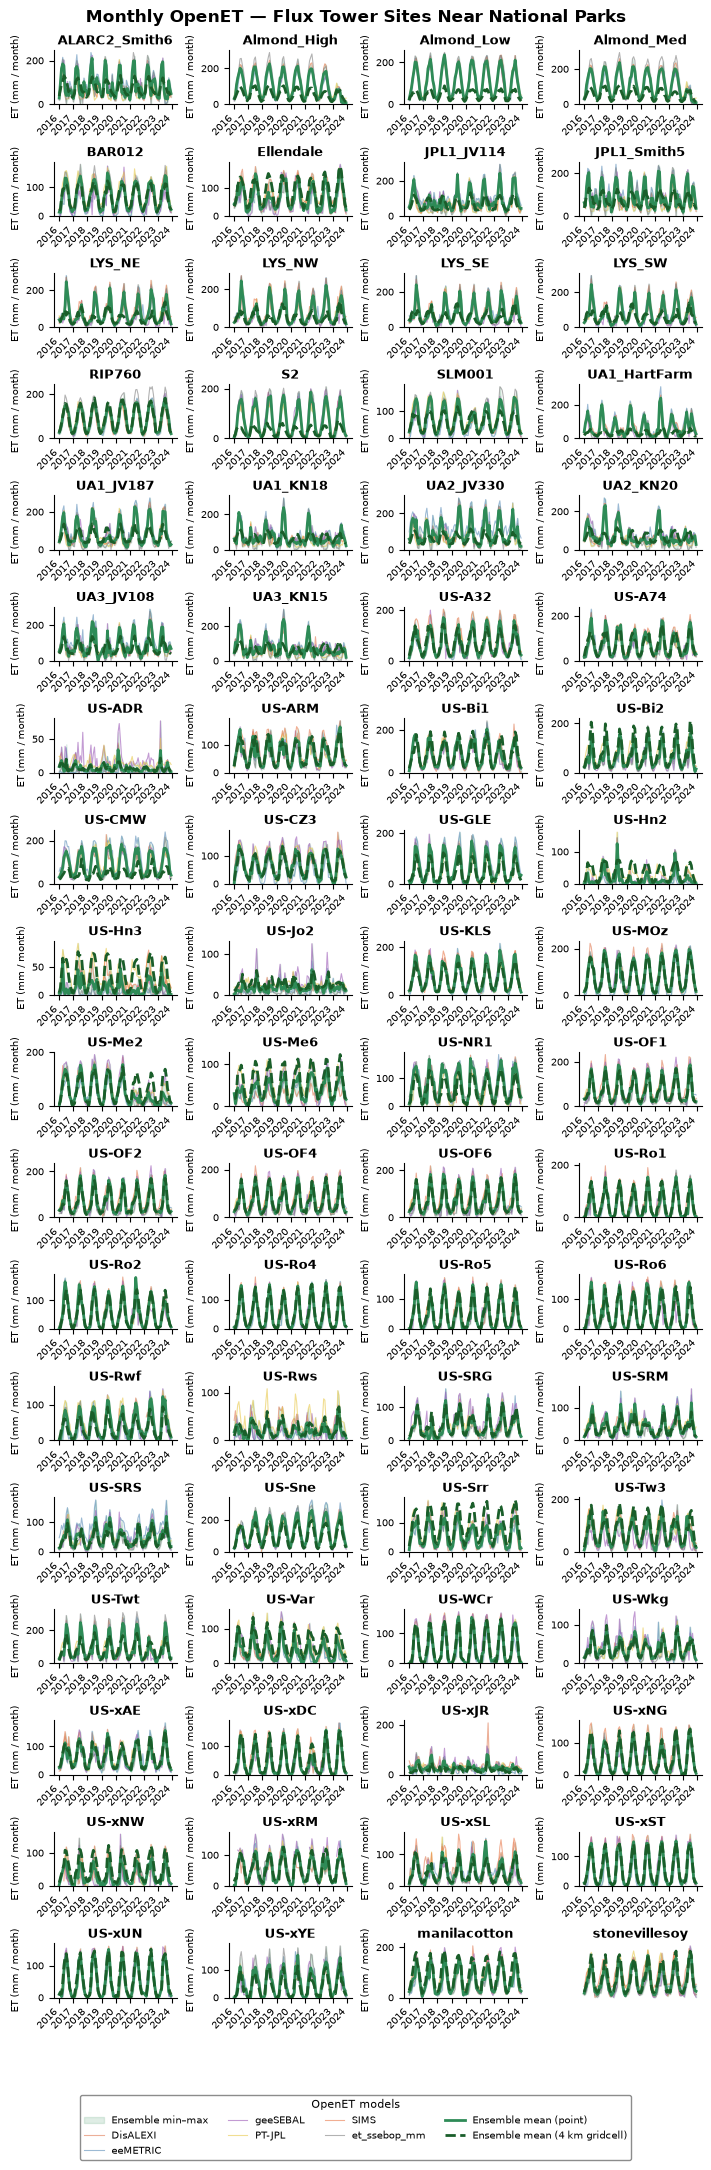

In [15]:
# ── Column definitions ────────────────────────────────────────────────────────
ENSEMBLE_COL = "et_ensemble_mm"
MIN_COL      = "et_ensemble_min_mm"
MAX_COL      = "et_ensemble_max_mm"

MODEL_COLS = [c for c in openet_df.columns
              if c.startswith("et_") and c not in
              [ENSEMBLE_COL, MIN_COL, MAX_COL]]

MODEL_COLORS = {
    "et_disalexi_mm": "#E07B54",
    "et_eemetric_mm": "#5B8DB8",
    "et_geesebal_mm": "#9B59B6",
    "et_ptjpl_mm":    "#E8C84A",
    "et_sims_mm":     "#E8784A",
}
MODEL_LABELS = {
    "et_disalexi_mm": "DisALEXI",
    "et_eemetric_mm": "eeMETRIC",
    "et_geesebal_mm": "geeSEBAL",
    "et_ptjpl_mm":    "PT-JPL",
    "et_sims_mm":     "SIMS",
}

# ── Merge gridcell ensemble into openet_df for plotting ───────────────────────
openet_plot_df = openet_df.merge(
    openet_gridcell_df[["site", "date", ENSEMBLE_COL]]
    .rename(columns={ENSEMBLE_COL: "et_ensemble_gc_mm"}),
    on=["site", "date"],
    how="left",
)

# ── Layout ────────────────────────────────────────────────────────────────────
sites   = sorted(openet_plot_df["site"].unique())
n_sites = len(sites)
n_cols  = 4
n_rows  = int(np.ceil(n_sites / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7, n_rows * 1.2),
    sharey=False,
    constrained_layout=True,
)
axes_flat = axes.flatten()

# ── Plot each site ────────────────────────────────────────────────────────────
for ax, site in zip(axes_flat, sites):
    sub = openet_plot_df[openet_plot_df["site"] == site].sort_values("date")

    # Ensemble min/max ribbon
    ax.fill_between(
        sub["date"],
        sub[MIN_COL],
        sub[MAX_COL],
        color="seagreen", alpha=0.15,
        label="Ensemble min–max",
    )

    # Individual model lines
    for col in MODEL_COLS:
        if col in sub.columns:
            ax.plot(
                sub["date"], sub[col],
                color=MODEL_COLORS.get(col, "grey"),
                linewidth=0.8, alpha=0.6,
                label=MODEL_LABELS.get(col, col),
            )

    # Point-sampled ensemble mean
    ax.plot(
        sub["date"], sub[ENSEMBLE_COL],
        color="seagreen", linewidth=2,
        label="Ensemble mean (point)", zorder=5,
    )

    # Gridcell-averaged ensemble mean — darker green
    ax.plot(
        sub["date"], sub["et_ensemble_gc_mm"],
        color="#1a5e2a", linewidth=2, linestyle="--",
        label="Ensemble mean (4 km gridcell)", zorder=6,
    )

    ax.set_title(site, fontsize=9, fontweight="bold", pad=4)
    ax.set_ylabel("ET (mm / month)", fontsize=7)
    ax.tick_params(axis="both", labelsize=7)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_ylim(bottom=0)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# ── Hide unused axes ──────────────────────────────────────────────────────────
for ax in axes_flat[n_sites:]:
    ax.set_visible(False)

# ── Shared legend in the first unused axis (or figure level) ─────────────────
legend_ax = axes_flat[n_sites] if n_sites < len(axes_flat) else axes_flat[-1]
legend_ax.set_visible(True)
legend_ax.axis("off")

for ax in axes_flat[n_sites:]:
    ax.set_visible(False)

handles, labels = axes_flat[n_sites - 1].get_legend_handles_labels()

fig.legend(
    handles, labels,
    loc            = "lower center",
    ncol           = len(handles)/2,
    fontsize       = 7,
    frameon        = True,
    framealpha     = 0.9,
    edgecolor      = "grey",
    title          = "OpenET models",
    title_fontsize = 8,
    bbox_to_anchor = (0.5, 0),
)

fig.suptitle(
    "Monthly OpenET — Flux Tower Sites Near National Parks",
    fontsize=12, fontweight="bold",
)

fig.get_layout_engine().set(rect=(0, 0.06, 1, 0.94))

plt.savefig("../Data/open_et/openet_faceted.png", dpi=600, bbox_inches="tight")
plt.show()

Now we'll download gridmet temperature and precipitation to feed into the NPS WBM

GridMET Climate Data — Flux Tower Points (2016–2023)

Fetches daily GridMET precipitation, temperature (max/min/mean), and
reference evapotranspiration at flux tower point locations.

**Two retrieval methods are provided — use whichever fits your setup:**

 | Method | Best for | Requires |
 |--------|----------|----------|
 | **A — Google Earth Engine** | Many points, large date range, no local storage | `earthengine-api`, GEE account |
 | **B — THREDDS / OPeNDAP** | Offline-friendly, no GEE account needed | `xarray`, `netCDF4` or `pydap` |

 Both methods produce an identical output DataFrame formatted for
 direct input into `nps_wbm_functions.py`.

 **GridMET variables fetched:**

 | GridMET band | Description | Native units | Output column |
 |---|---|---|---|
 | `pr`   | Precipitation        | mm day⁻¹ | `ppt_mm`  |
 | `tmmx` | Maximum temperature  | K         | `tmax_C`  |
 | `tmmn` | Minimum temperature  | K         | `tmin_C`  |
 | `tmean`| Mean temperature     | K (derived)| `tmean_C` |
 | `pet`  | Reference ET (PM grass) | mm day⁻¹ | `pet_gridmet_mm` |
 | `etr`  | Reference ET (PM alfalfa) | mm day⁻¹ | `etr_gridmet_mm` |
 | `vs`   | Wind speed (10 m)    | m s⁻¹     | `wind_10m_ms`, and `wind_ms` (corrected to 2 m via `wbm.get_wind_speed_2m()` for notebook 06's Penman-Monteith comparison) |

 **If you already ran this cell before wind was added:** this cell's incremental
 caching (`wbm.load_and_filter_missing`) only checks whether a site's *name* is
 already present in `climate_gee_flux_towers_2016_2023.csv` -- it has no way to
 know that a column was added to the schema later, so any site fetched before
 `wind_10m_ms`/`wind_ms` existed will silently keep `NaN` wind forever, even after
 you re-run this cell (it looks "already cached" and gets skipped). This is not
 just a cosmetic gap: `wbm.model.nps_wbm()`'s Penman-Monteith branch only checks
 whether a `wind_ms` *column* exists, not whether its values are valid, so a
 NaN wind column silently produces NaN PET/AET for every day at that site --
 and pandas' `.groupby(...).sum()` then silently reports that as `0.0 mm/month`
 AET at the monthly-aggregation step used everywhere downstream, with no error
 or warning. **Fix:** delete `../Data/gridmet_cache/climate_gee_flux_towers_2016_2023.csv`
 entirely and re-run this cell once -- that forces every site to be treated as
 missing and re-fetched fresh with the current `GRIDMET_BANDS` (which already
 includes `vs`), rather than trying to backfill just the affected sites.

In [16]:
# ── Incremental caching: only fetch gridMET climate for sites not already cached ──
GRIDMET_CACHE = "../Data/gridmet_cache/climate_gee_flux_towers_2016_2023.csv"

existing_climate_df, missing_climate_sites = wbm.load_and_filter_missing(
    all_sites=flux_towers["site"].tolist(),
    cache_path=GRIDMET_CACHE,
    site_col="site",
    parse_dates=["date"],
)

if not missing_climate_sites:
    print(f"All {len(flux_towers)} sites already cached in {GRIDMET_CACHE} -- skipping GEE.")
    climate_gee = existing_climate_df

    print(f"climate_gee shape: {climate_gee.shape}")
    print(f"Sites           : {sorted(climate_gee['site'].unique())}")
    print(f"Date range      : {climate_gee['date'].min().date()} \u2192 {climate_gee['date'].max().date()}")
    print(f"Columns         : {climate_gee.columns.tolist()}")
    print(f"\nSample:")
    print(climate_gee.head(6).to_string(index=False))

else:
    print(f"Fetching gridMET climate for {len(missing_climate_sites)} new site(s): {missing_climate_sites}")
    print(f"({len(flux_towers) - len(missing_climate_sites)} site(s) already cached, skipped.)")

    # Google Earth Engine
    #
    # Uses `ee.ImageCollection.getRegion()` to extract a time series at each
    # point in one API call per variable group.  Efficient for many points
    # across multi-year periods.

    GRIDMET_BANDS = ["pr", "tmmx", "tmmn", "etr", "vs"]   # vs = wind speed at 10 m, m/s

    # ── One API call per (missing) site, full date range ─────────────────────────
    # Each call: 1 point \u00d7 ~2,922 images \u00d7 4 bands \u2248 trivial payload.

    site_frames = []

    missing_rows = [row for row in flux_towers.itertuples() if row.site in missing_climate_sites]

    for row in missing_rows:
        print(f"  Fetching {row.site} ({row.ecosystem}, {row.state}) ...", end=" ")

        single_point_fc = ee.FeatureCollection([
            ee.Feature(
                ee.Geometry.Point([row.x, row.y]),
                {"site": row.site}
            )
        ])

        gridmet_ic = (
            ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")
            .filterDate(START_DATE, END_DATE)
            .select(GRIDMET_BANDS)
        )

        try:
            raw  = gridmet_ic.getRegion(single_point_fc, scale=4000).getInfo()
            df   = pd.DataFrame(raw[1:], columns=raw[0])
            df["date"] = pd.to_datetime(df["time"], unit="ms").dt.normalize()
            df   = df.dropna(subset=GRIDMET_BANDS)
            df["site"] = row.site   # attach label directly \u2014 no nearest-neighbour needed
            site_frames.append(df)
            print(f"{len(df):,} rows")

        except Exception as e:
            print(f"\n    \u26a0\ufe0f  {row.site} failed: {e}")

        time.sleep(0.5)   # stay well under GEE request rate limits

    if not site_frames:
        raise RuntimeError("No gridMET data was successfully downloaded for the missing sites.")

    # ── Combine and clean ─────────────────────────────────────────────────────────
    gee_df = (
        pd.concat(site_frames, ignore_index=True)
        .rename(columns={"longitude": "x", "latitude": "y"})
    )

    print(f"\nNew rows: {len(gee_df):,}  (expect ~{len(missing_rows) * 2922:,})")
    print(gee_df["site"].value_counts().sort_index())

    # ── Unit conversions and rename for WBM ──────────────────────────────────────
    K_TO_C = 273.15

    new_climate_df = (
        gee_df
        .assign(
            ppt_mm         = lambda d: d["pr"],
            tmax_C         = lambda d: d["tmmx"] - K_TO_C,
            tmin_C         = lambda d: d["tmmn"] - K_TO_C,
            tmean_C        = lambda d: (d["tmmx"] + d["tmmn"]) / 2 - K_TO_C,
            etr_gridmet_mm = lambda d: d["etr"],
            wind_10m_ms    = lambda d: d["vs"],
            # FAO-56 Penman-Monteith (notebook 06) needs wind at 2 m, not
            # gridMET's native 10 m -- corrected here so it rides along with
            # everything else rather than needing its own GEE pull later.
            wind_ms        = lambda d: get_wind_speed_2m(d["vs"].to_numpy(dtype=float), z=10.0),
            GCM            = lambda d: d["site"],
        )
        .loc[:, ["date", "x", "y", "site", "GCM",
                "ppt_mm", "tmax_C", "tmin_C", "tmean_C",
                "etr_gridmet_mm", "wind_10m_ms", "wind_ms"]]
        .sort_values(["site", "date"])
        .reset_index(drop=True)
    )

    # ── Merge with existing cache and save ────────────────────────────────────────
    climate_gee = wbm.merge_and_save_cache(
        cache_path=GRIDMET_CACHE,
        existing_df=existing_climate_df,
        new_rows_df=new_climate_df,
        sort_cols=["site", "date"],
    )

    print(f"\nSaved to {GRIDMET_CACHE}")
    print(f"\nclimate_gee shape: {climate_gee.shape}")
    print(climate_gee.head(8).to_string(index=False))


Fetching gridMET climate for 81 new site(s): ['US-A32', 'US-A74', 'US-ADR', 'US-ARM', 'US-Bi1', 'US-Bi2', 'US-CMW', 'US-CZ3', 'US-GLE', 'US-Hn2', 'US-Hn3', 'US-IB1', 'US-IB2', 'US-Jo2', 'US-KLS', 'US-KM4', 'US-Me2', 'US-Me6', 'US-MOz', 'US-NC2', 'US-NC3', 'US-NC4', 'US-NR1', 'US-Ro1', 'US-Ro2', 'US-Ro4', 'US-Ro5', 'US-Ro6', 'US-Rwf', 'US-Rws', 'US-Sne', 'US-SRG', 'US-SRM', 'US-Srr', 'US-SRS', 'US-Tw3', 'US-Twt', 'US-Var', 'US-WCr', 'US-Wkg', 'US-xAE', 'US-xDC', 'US-xDL', 'US-xDS', 'US-xJR', 'US-xNG', 'US-xNW', 'US-xRM', 'US-xSB', 'US-xSL', 'US-xST', 'US-xUN', 'US-xYE', 'Ellendale', 'manilacotton', 'stonevillesoy', 'US-OF1', 'US-OF2', 'US-OF4', 'US-OF6', 'S2', 'ALARC2_Smith6', 'Almond_High', 'Almond_Low', 'Almond_Med', 'JPL1_JV114', 'JPL1_Smith5', 'UA1_HartFarm', 'UA1_JV187', 'UA1_KN18', 'UA2_JV330', 'UA2_KN20', 'UA3_JV108', 'UA3_KN15', 'LYS_NE', 'LYS_NW', 'LYS_SE', 'LYS_SW', 'BAR012', 'RIP760', 'SLM001']
(0 site(s) already cached, skipped.)
  Fetching US-A32 (Grasslands, OK) ... 2,921 